In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
pd.read_excel('C:/Users/sushe/Documents/Kantar/Fraud Detection/data/dataset_20260430.xlsx').to_csv('C:/Users/sushe/Documents/Kantar/Fraud Detection/data/datasets.csv', index=False)

In [3]:
Datasource = 'C:/Users/sushe/Documents/Kantar/Fraud Detection/data/datasets.csv'
OUT_DIR = "C:/Users/sushe/Documents/Kantar/Fraud Detection/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
def load_data(path):
    df = pd.read_csv(path, parse_dates=["registration_timestamp"])
    return df

In [5]:
def daily_fraud_profile(df):
    g = df.set_index("registration_timestamp").resample("D")["is_fraud"].agg(
        registrations="size", frauds="sum"
    )
    g["fraud_rate"] = g["frauds"] / g["registrations"]
    return g

In [6]:
def hourly_fraud_profile(df):
    g = df.set_index("registration_timestamp").resample("h")["is_fraud"].agg(
        registrations="size", frauds="sum"
    )
    g["fraud_rate"] = g["frauds"] / g["registrations"]
    return g

In [7]:
def robust_z(s):
        med = s.median()
        mad = (s - med).abs().median()
        scale = 1.4826 * mad if mad > 0 else s.std(ddof=0)
        return (s - med) / (scale if scale else 1.0)

In [8]:
def detect_anomalous_window(hourly, z_thresh: float = 5.0):
    out = hourly.copy()
    out["vol_z"] = robust_z(out["registrations"])
    out["rate_z"] = robust_z(out["fraud_rate"].fillna(0))
    out["is_anomaly"] = (out["vol_z"] > z_thresh) & (out["rate_z"] > z_thresh)
    return out

Loaded 50,000 rows
Overall fraud rate: 5.00%
Date range: 2025-01-01 00:00:56.670990  ->  2025-01-30 23:59:45.957599

Top 5 days by fraud rate:
                        registrations  frauds  fraud_rate
registration_timestamp                                   
2025-01-11                       2128     574        27.0
2025-01-12                       1758      90         5.1
2025-01-03                       1626      78         4.8
2025-01-22                       1642      77         4.7
2025-01-25                       1588      74         4.7

Anomalous hours flagged (volume AND fraud-rate outliers):
                        registrations  frauds  fraud_rate      vol_z     rate_z
registration_timestamp                                                         
2025-01-11 01:00:00               246     177        72.0  20.009893  29.460440
2025-01-11 02:00:00               250     172        68.8  20.459553  28.097307
2025-01-11 03:00:00               232     165        71.1  18.436081  29

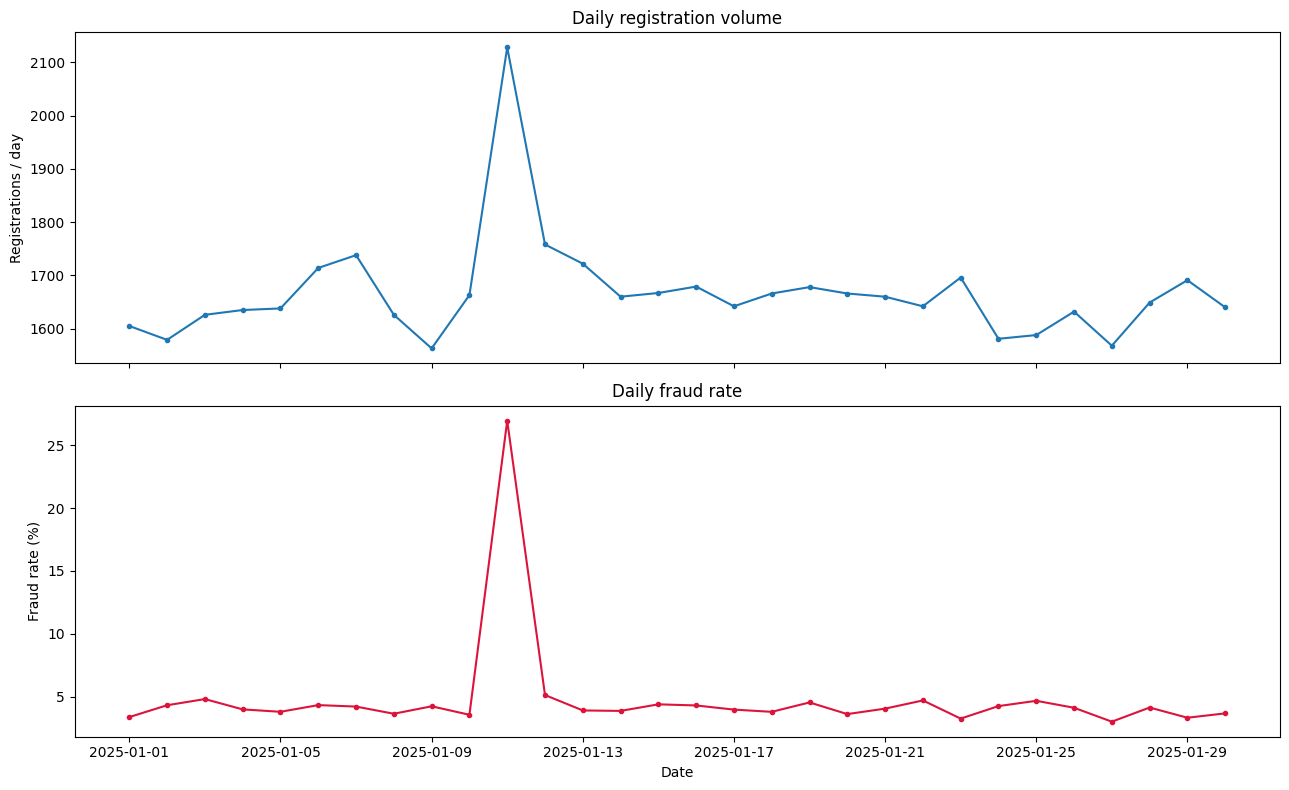

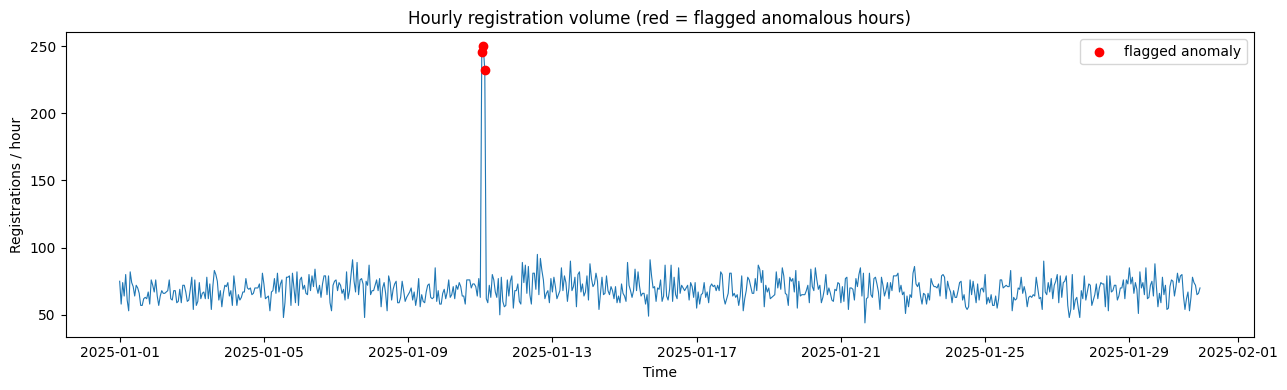

In [9]:
df = load_data(Datasource)
print(f"Loaded {len(df):,} rows")
print(f"Overall fraud rate: {df['is_fraud'].mean():.2%}")
print(f"Date range: {df['registration_timestamp'].min()}  ->  {df['registration_timestamp'].max()}\n")

daily = daily_fraud_profile(df)
top_days = daily.sort_values("fraud_rate", ascending=False).head(5)
print("Top 5 days by fraud rate:")
print(top_days.assign(fraud_rate=lambda d: (d["fraud_rate"] * 100).round(1)).to_string())
print()
    
hourly = hourly_fraud_profile(df)
flagged = detect_anomalous_window(hourly, z_thresh=5.0)
anomalies = flagged[flagged["is_anomaly"]]

print("Anomalous hours flagged (volume AND fraud-rate outliers):")
print(anomalies[["registrations", "frauds", "fraud_rate", "vol_z", "rate_z"]].assign(fraud_rate=lambda d: (d["fraud_rate"] * 100).round(1)).to_string())

if not anomalies.empty:
    start, end = anomalies.index.min(), anomalies.index.max() + pd.Timedelta(hours=1)
    print(f"\nDETECTED ANOMALY WINDOW: {start}  ->  {end}")
    attack = df[(df["registration_timestamp"] >= start) & (df["registration_timestamp"] < end)]
    print(f"Registrations in window: {len(attack):,}")
    print(f"Fraud rate in window:    {attack['is_fraud'].mean():.1%}")
    print(f"Share of ALL fraud in this 3-4h window: " f"{attack['is_fraud'].sum() / df['is_fraud'].sum():.1%}")

    
fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
ax[0].plot(daily.index, daily["registrations"], marker="o", ms=3)
ax[0].set_ylabel("Registrations / day"); ax[0].set_title("Daily registration volume")
ax[1].plot(daily.index, daily["fraud_rate"] * 100, marker="o", ms=3, color="crimson")
ax[1].set_ylabel("Fraud rate (%)"); ax[1].set_title("Daily fraud rate")
ax[1].set_xlabel("Date")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/task1_daily_profile.png", dpi=120)

fig2, ax2 = plt.subplots(figsize=(13, 4))
ax2.plot(hourly.index, hourly["registrations"], lw=0.8)
ax2.scatter(anomalies.index, anomalies["registrations"], color="red", zorder=5, label="flagged anomaly")
ax2.set_title("Hourly registration volume (red = flagged anomalous hours)")
ax2.set_ylabel("Registrations / hour"); ax2.set_xlabel("Time"); ax2.legend()
fig2.tight_layout()
fig2.savefig(f"{OUT_DIR}/task1_hourly_anomaly.png", dpi=120)
print(f"\nPlots saved to {OUT_DIR}/")